# System Configuration

## Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

## Parameter Values

In [2]:
z_var = 1.0  # Variance of z
d_var = 0.1  # Variance of noise d
n_samples = 10000000  # Monte Carlo simulation count
n_points = 100  # Number of points for calculating theoretical moments
y_th = 0.1  # Deviation threshold of y values
y_range = 3  # Range of y ie. [-y_range,y_range]

## Function Definitions

In [3]:
# Non-linear function
def phi(z):
    return np.tanh(z)

# Likelihood p(y|z) with Gaussian noise on d
def f_y_z(y, z, d_var):
    return norm.pdf(y, loc = phi(z), scale = np.sqrt(d_var))

# Prior on z (Gaussian with mean 0 and variance z_var)
def f_z(z, z_var):
    return norm.pdf(z, loc = 0, scale = np.sqrt(z_var))

# Numerical integration of E(z|y) and Var(z|y)
def compute_moments(y, z_var, d_var):

    # Compute E(z|y)
    A0, _ = quad(lambda z: f_y_z(y, z, d_var) * f_z(z, z_var), -np.inf, np.inf)
    A1, _ = quad(lambda z: z * f_y_z(y, z, d_var) * f_z(z, z_var), -np.inf, np.inf)
    E_z_y = A1 / A0

    # Compute Var(z|y)
    A2, _ = quad(lambda z: (z**2) * f_y_z(y, z, d_var) * f_z(z, z_var), -np.inf, np.inf)
    Var_z_y = A2 / A0 - E_z_y**2

    return E_z_y, Var_z_y

# Posterior Moments

## Theoretical Moments

In [4]:
y_values = np.linspace(-y_range, y_range, n_points)

z_means = []
z_vars = []

for y in y_values:
    E_z_y, Var_z_y = compute_moments(y, z_var, d_var)
    z_means.append(E_z_y)
    z_vars.append(Var_z_y)

## Experimental Moments

In [5]:
z_samples = np.random.normal(0, np.sqrt(z_var), n_samples)
d_samples = np.random.normal(0, np.sqrt(d_var), n_samples)
y_samples = phi(z_samples) + d_samples

z_means_emp = []
z_vars_emp = []

for y in y_values:
    close_samples = (np.abs(y_samples - y) < y_th)
    if np.sum(close_samples) > 0:
        E_z_y = np.mean(z_samples[close_samples])
        Var_z_y = np.var(z_samples[close_samples])
    else:
        E_z_y = 0
        Var_z_y = 0

    z_means_emp.append(E_z_y)
    z_vars_emp.append(Var_z_y)

## Verification

In [6]:
cs = CubicSpline(y_values, z_means)

mean_var = np.mean(z_vars)
mean_mse = np.mean((z_samples - cs(y_samples)) ** 2)

print(f"Mean of posterior variances: {mean_var:.5f}")
print(f"Mean of MSE between z[i] and E(z|y[i]): {mean_mse:.5f}")

Mean of posterior variances: 0.26688
Mean of MSE between z[i] and E(z|y[i]): 0.25321


## Moment Plots

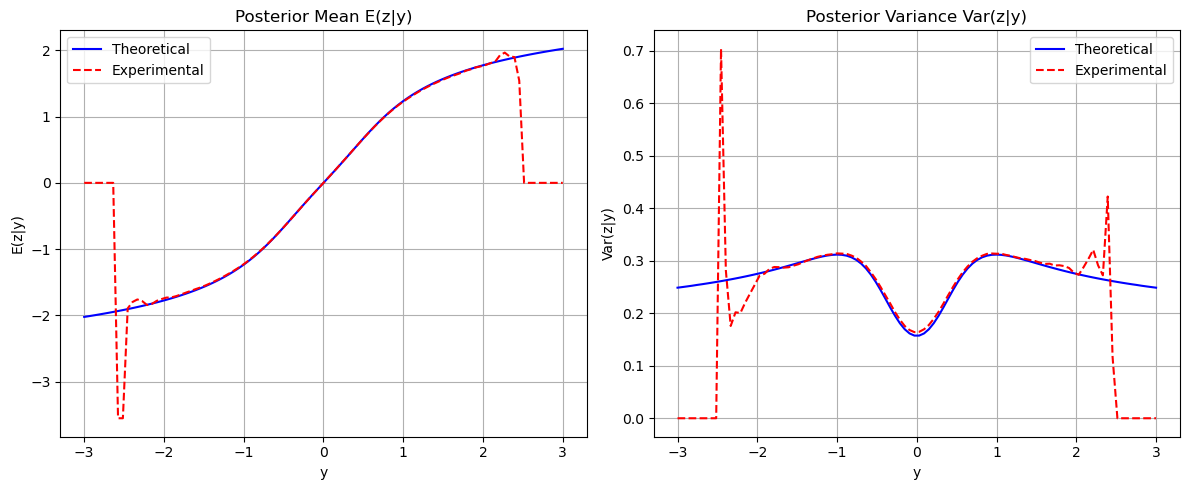

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(y_values, z_means, color="blue", label="Theoretical")
plt.plot(y_values, z_means_emp, '--', color="red", label="Experimental")
plt.xlabel("y")
plt.ylabel("E(z|y)")
plt.title("Posterior Mean E(z|y)")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(y_values, z_vars, color="blue", label="Theoretical")
plt.plot(y_values, z_vars_emp, '--', color="red", label="Experimental")
plt.xlabel("y")
plt.ylabel("Var(z|y)")
plt.title("Posterior Variance Var(z|y)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Performance

In [8]:
z_var = 1  # Variance of z
d_var = 0.1  # Variance of noise d
n_samples = 100  # Monte Carlo simulation count
n_points = 100  # Number of points for calculating theoretical moments
y_th = 0.1  # Deviation threshold of y values
y_range = 5  # Range of y ie. [-y_range,y_range]

In [9]:
y_values = np.linspace(-y_range, y_range, n_points)
z_est = []
for y in y_values:
    E_z_y, Var_z_y = compute_moments(y, z_var, d_var)
    z_est.append(E_z_y)

In [10]:
z_samples = np.random.normal(0, np.sqrt(z_var), n_samples)
phi_z_samples = phi(z_samples)
d_samples = np.random.normal(0, np.sqrt(d_var), n_samples)
y_samples = phi_z_samples + d_samples

In [11]:
z_dummy = np.linspace(-y_range, y_range, n_points)
y_dummy = phi(z_dummy)

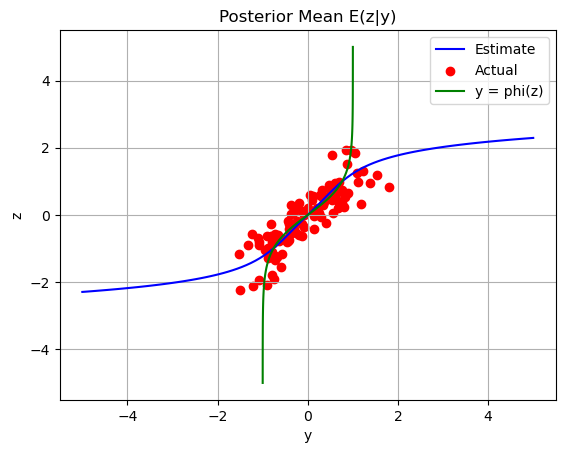

In [12]:
plt.figure()
plt.plot(y_values, z_est, color="blue", label="Estimate")
plt.scatter(y_samples, z_samples, color="red", label="Actual")
plt.plot(y_dummy, z_dummy, color="green", label="y = phi(z)")
plt.xlabel("y")
plt.ylabel("z")
plt.title("Posterior Mean E(z|y)")
plt.legend()
plt.grid()
plt.show()